In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Importation des librairies
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import chi2_contingency, pearsonr, spearmanr, kendalltau, f_oneway, kruskal, shapiro, levene, kruskal


In [5]:
#Importation du fichier web.xlsx
df_transactions = pd.read_csv("Transactions.csv", sep=';')
#Importation du fichier erp.xlsx
df_customers = pd.read_csv("customers.csv", sep=';')
#importation du fichier liaison.xlsx
df_products = pd.read_csv("products.csv", sep=';')

/tmp/ipython-input-3051139531.py:2: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv("Transactions.csv", sep=';')


In [6]:
#EXPLORATION DES DONNEES

In [7]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [8]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [9]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [10]:
# JOINTURE

In [11]:
df_1 = df_transactions.merge(df_customers, on="client_id", how="left")

df = df_1.merge(df_products, on="id_prod", how="left")

df = df.dropna()


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id_prod     687534 non-null  object 
 1   date        687534 non-null  object 
 2   session_id  687534 non-null  object 
 3   client_id   687534 non-null  object 
 4   sex         687534 non-null  object 
 5   birth       687534 non-null  float64
 6   price       687534 non-null  float64
 7   categ       687534 non-null  float64
dtypes: float64(3), object(5)
memory usage: 47.2+ MB


In [13]:
df.to_csv("jointure_export.csv", index=False)

In [14]:
#Recherche des clients BTOB Chiffre d'affaires par client

ca_client = df.groupby('client_id')['price'].sum()


#Suppression des clients top 4 clients CA
top4_clients = ["c_1609", "c_4958", "c_6714", "c_3454"]

df_without_top4 = df.drop(df[df["client_id"].isin(top4_clients)].index)

print(df_without_top4)


       id_prod                        date session_id client_id sex   birth  \
0       0_1259  2021-03-01 00:01:07.843138        s_1     c_329   f  1967.0   
1       0_1390  2021-03-01 00:02:26.047414        s_2     c_664   m  1960.0   
2       0_1352  2021-03-01 00:02:38.311413        s_3     c_580   m  1988.0   
3       0_1458  2021-03-01 00:04:54.559692        s_4    c_7912   f  1989.0   
4       0_1358  2021-03-01 00:05:18.801198        s_5    c_2033   f  1956.0   
...        ...                         ...        ...       ...  ..     ...   
687529   1_508  2023-02-28 23:49:03.148402   s_348444    c_3573   f  1996.0   
687530    2_37  2023-02-28 23:51:29.318531   s_348445      c_50   f  1994.0   
687531   1_695  2023-02-28 23:53:18.929676   s_348446     c_488   f  1985.0   
687532  0_1547  2023-02-28 23:58:00.107815   s_348447    c_4848   m  1953.0   
687533  0_1398  2023-02-28 23:58:30.792755   s_348435    c_3575   f  1981.0   

        price  categ  
0       11.99    0.0  
1    

In [28]:
#On pose les hypothese sur les test + variable de risque

#H0 il n'existe pas de corrélation entre les deux variables
#H1 il existe une correlation / un lien significatif entre les deux variables
#Risque 5% si p<0.05 alors -> Corrélation

Khi2 =  22.67        p value =  1e-05
V de Cramer =  0.01


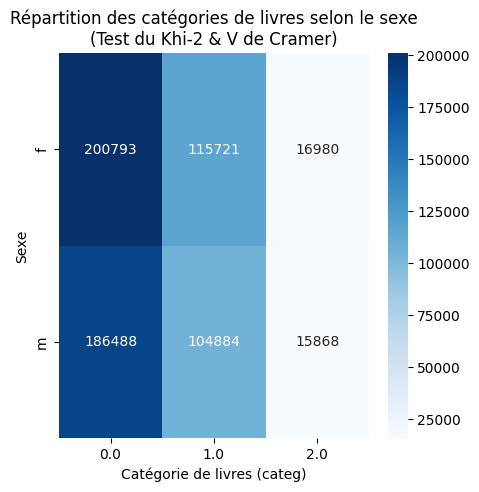

In [27]:
#PARTIE JULIE / TEST STATISTIQUE : GENRE & CATEGORIE -> KHI2 pour comparer des valeurs quali + V de Cramer


#Realisation de la matrice via crosstab pour comparer les données (tableau de contingence)
matrice = pd.crosstab(df_without_top4['sex'], df_without_top4['categ'])

#TEST DE VALIDITE DU TEST : variables quali et suffisantes sur des échantillons du DF indépendant (Genre et catégorie)

#Khi2 test sur tableau de contingence
chi2, p, doc, expected = chi2_contingency(matrice)

print("Khi2 = ", round(chi2, 2), "       p value = ", round(p, 5))

#V de Cramer pour voir vraiment une correlation forte ou si aucune correlation vraiment importante malgré une forme de dépendance entre sexe et catégorie
n = matrice.sum().sum()
cramer_v = np.sqrt(chi2 / (n * (min(matrice.shape)-1)))
print("V de Cramer = ", round(cramer_v, 2))

#Graph bi varié
plt.figure(figsize=(5,5))
sns.heatmap(matrice, annot=True, fmt="d", cmap="Blues")
plt.title("Répartition des catégories de livres selon le sexe\n(Test du Khi-2 & V de Cramer)")
plt.xlabel("Catégorie de livres (categ)")
plt.ylabel("Sexe")
plt.show()


#Conclusion : H1 -> corrélation existante car 158 nettement supérieur à la valeur dof ((nb de ligne -1) x (nb de colonne -1)) ET donc valeur p = 0 soit <0.05 MAIS valeur V de cramer très faible 0.02 sur 1 au V de Cramer


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 640734.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro :  0.97  p : 0.0
Shapiro : 0.96  p : 0.0
Spearman =  -0.2         p-value = 0.0


/tmp/ipython-input-122780615.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


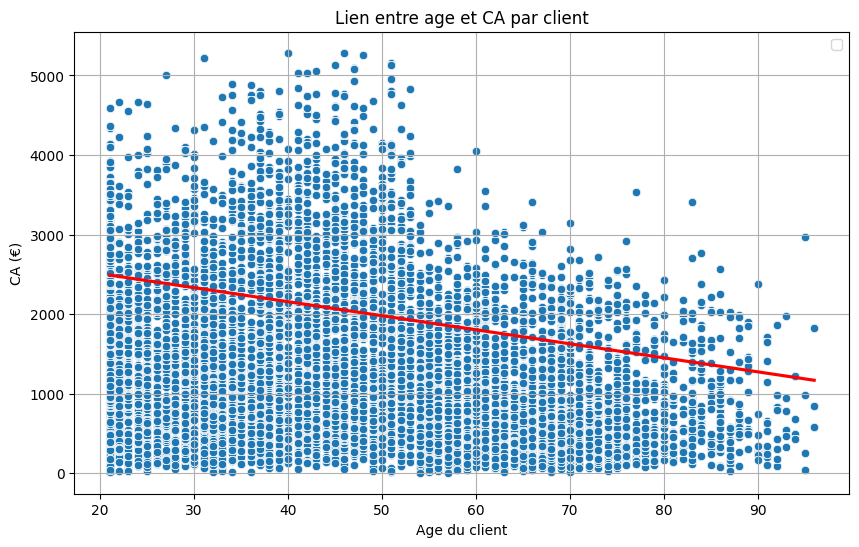

In [16]:

##PARTIE JULIE / TEST STATISTIQUE : AGE & MONTANT d'achat ->



#TEST SPEARMAN car 2 variables quanti + non normales + pas forcement des valeurs linéaires

#Age via colonne birth recalculé sur le df total
df_without_top4['age'] = 2025 - df_without_top4['birth']
ca_client = df_without_top4.groupby('client_id')['price'].sum().reset_index()

#Jointure d'age et ca_client pour étuider age + CA
df_age_ca = ca_client.merge(df_without_top4[['client_id','age']], on='client_id')




#TEST conditions d'utilisation et choix du test

shapiro_age = shapiro(df_age_ca['age'])
shapiro_ca = shapiro(df_age_ca['price'])

print("Shapiro : ", round(shapiro_age.statistic,2), " p :", round(shapiro_age.pvalue,2))
print("Shapiro :", round(shapiro_ca.statistic,2), " p :", round(shapiro_ca.pvalue,2))

#p value < à 0.05 non normal donc Spearman préférable.



#Test de Spearman
r_spearman, p_spearman = spearmanr(df_age_ca['age'], df_age_ca['price'])

print("Spearman = ", round(r_spearman, 2), "        p-value =", round(p_spearman, 5))

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_age_ca, x='age', y='price')
sns.regplot(data=df_age_ca, x='age', y='price', scatter=False, color='red', line_kws={'label':"Trend"})
plt.title("Lien entre age et CA par client")
plt.xlabel("Age du client")
plt.ylabel("CA (€)")
plt.legend()
plt.grid(True)
plt.show()

#Conclusion : H1 -> Correlation

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro :  0.97  p : 0.0
Shapiro : 0.82  p : 0.0
Spearman = 0.13         p-value = 0.0


/tmp/ipython-input-1743322966.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


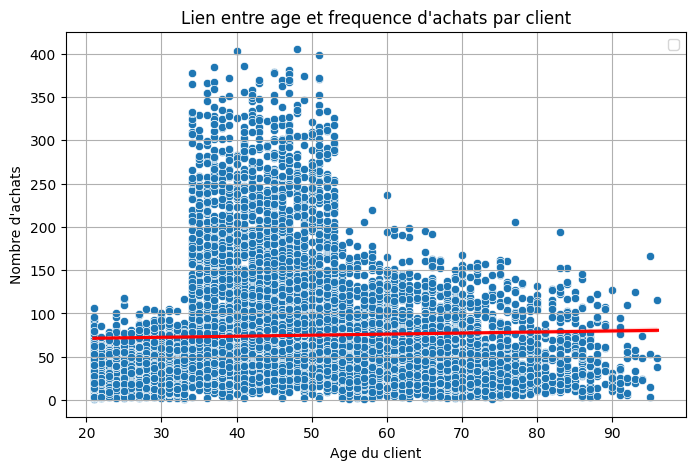

In [17]:
#PARTIE JULIE / TEST STATISTIQUE : AGE & Frequence des achats ->

#Colonne date bien en datetime

#Calcul frequence achat par client
freq_achat = df_without_top4.groupby('client_id')['date'].count().reset_index(name='freq')

#Jointure avec age déjà calculé plus haut
df_age_unique = df_without_top4.drop_duplicates(subset=['client_id'])[['client_id', 'age']]
df_age_freq = freq_achat.merge(df_age_unique, on='client_id')

# TEST conditions d'utilisation et choix du test
shapiro_age = shapiro(df_age_freq['age'])
shapiro_freq = shapiro(df_age_freq['freq'])

print("Shapiro : ", round(shapiro_age.statistic,2), " p :", round(shapiro_age.pvalue,2))
print("Shapiro :", round(shapiro_freq.statistic,2), " p :", round(shapiro_freq.pvalue,2))

#p value < à 0.05 non normal donc Spearman préférable.

#TEST spearman car 2 variables quanti non linéraire et non normales
r_spearman, p_spearman = spearmanr(df_age_freq['age'], df_age_freq['freq'])
print("Spearman =", round(r_spearman, 2), "        p-value =", round(p_spearman, 5))

#Graphique
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_age_freq, x='age', y='freq')
sns.regplot(data=df_age_freq, x='age', y='freq', scatter=False, color='red', line_kws={'label':"Trend"})
plt.title("Lien entre age et frequence d'achats par client")
plt.xlabel("Age du client")
plt.ylabel("Nombre d'achats")
plt.legend()
plt.grid(True)
plt.show()

#Conclusion : H1 -> Correlation


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro :  0.97  p : 0.0
Shapiro : 0.82  p : 0.0
Spearman = -0.33 p-value = 0.0


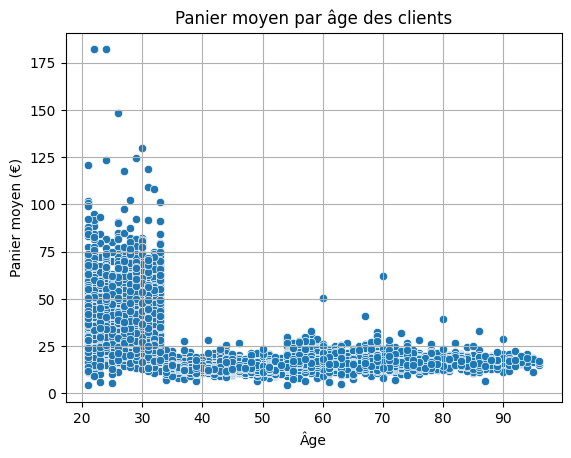

In [18]:
#PARTIE JULIE / TEST STATISTIQUE : AGE & Panier moyen ->

#Regroupement table par client avec CA et nb de transac + age

client_panierMoyen = df_without_top4.groupby('client_id').agg(
    CA=('price', 'sum'),
    transac=('price', 'count'),
    age=('age', 'first')  # même âge pour chaque client
)

#Calcul colonne panier moyen par client sur toutes ses transac
client_panierMoyen['panier_moyen'] = client_panierMoyen['CA'] / client_panierMoyen['transac']


# TEST conditions d'utilisation et choix du test
shapiro_age = shapiro(client_panierMoyen['age'])
shapiro_panier_moyen = shapiro(client_panierMoyen['panier_moyen'])

print("Shapiro : ", round(shapiro_age.statistic,2), " p :", round(shapiro_age.pvalue,2))
print("Shapiro :", round(shapiro_freq.statistic,2), " p :", round(shapiro_freq.pvalue,2))

#p value < à 0.05 non normal donc Spearman préférable.

#Test Spearman pour 2 variables quanti non linéraire et non normales
r_spearman, p_spearman = spearmanr(client_panierMoyen['age'], client_panierMoyen['panier_moyen'])


print("Spearman =", round(r_spearman, 2), "p-value =", round(p_spearman, 2))

#plt.figure(figsize=(10,6))
sns.scatterplot(
    data=client_panierMoyen,
    x='age',
    y='panier_moyen'
)
plt.title("Panier moyen par âge des clients")
plt.xlabel("Âge")
plt.ylabel("Panier moyen (€)")
plt.grid(True)
plt.show()

#Conclusion : H1 -> petite correlation dans le sens d'un panier moyen qui baisse avec l'age

Test de Levene : 24651.78  p : 0.0
Anova = 39705.52 p-value = 0.0
Kruskal-Wallis = 71359.73 p-value = 0.0


<Axes: xlabel='categ', ylabel='age'>

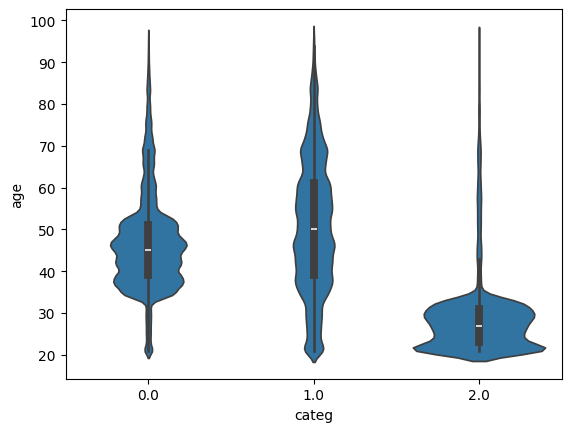

In [20]:
#PARTIE JULIE / TEST STATISTIQUE : AGE & categorie de livre acheté ->

#Construire une liste d'âges pour chaque catégorie
ages_par_categ = [ages for _, ages in df_without_top4.groupby('categ')['age']]

#TEST d'utilisation -> variances (Levene)
stat_levene, p_levene = levene(*ages_par_categ)
print("Test de Levene :", round(stat_levene,2), " p :", round(p_levene,2))

#Openclassroom demande Anova possible car beaucoup de valeur mais il faudrait plutot utiliser une test Kruskall-Wallis (non paramétrique) aux vues du test de Levene

#ANOVA et kruskall possible à utiliser car une variable quanti et une quali avec de nombreuses données dans l'échantillon (DF à + de 600k lignes)
r_anova, p_anova = f_oneway(*ages_par_categ)
r_kw, p_kw = kruskal(*ages_par_categ)

print("Anova =", round(r_anova, 2), "p-value =", round(p_anova, 2))
print("Kruskal-Wallis =", round(r_kw, 2), "p-value =", round(p_kw, 2))

sns.violinplot(x='categ', y='age', data=df_without_top4)

#Conclusion : H1 -> vrai différences d'age et dispersion en fonction des catégories de livres (anova regarder la variance des ages au sein des groupes et entre les différents groupes pour voir si il y a une correlation entre age et categ)

